In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Raíz del proyecto
PROJECT_ROOT = Path().resolve().parents[1]
# Ruta a la carpeta de datos procesados
path = PROJECT_ROOT / "data" / "processed"

# Cargar los archivos de valores anuales
produccion = pd.read_csv(path / "produccion_caldas_municipal_2007-2024.csv")
precipitacion = pd.read_csv(path / "precipitacion_caldas_anio_2005-2025.csv")
ndvi = pd.read_csv(path / "ndvi_caldas_anio_2005-2025.csv")
temperatura = pd.read_csv(path / "temperatura_caldas_anio_2005-2025.csv")
evapotranspiracion = pd.read_csv(path / "evapotranspiracion_caldas_anio_2005-2025.csv")

In [3]:
produccion = produccion.rename(columns={
    "Municipio": "MP_NOMBRE",
    "MpNombre": "municipio",
    "Año": "anio",
    "Producción (t)": "produccion_t"
})

In [4]:
display(produccion.head())
display(precipitacion.head())
display(ndvi.head())
display(temperatura.head())
display(evapotranspiracion.head())

,MP_NOMBRE,municipio,date,anio,produccion_t
0,AGUADAS,Aguadas,2007-12-31,2007,4063.0
1,AGUADAS,Aguadas,2008-12-31,2008,3458.0
2,AGUADAS,Aguadas,2009-12-31,2009,4110.0
3,AGUADAS,Aguadas,2010-12-31,2010,3800.0
4,AGUADAS,Aguadas,2011-12-31,2011,3939.0


,municipio,date,anio,precip_mm,precip_mean_mm,precip_max_mm,n_pixeles
0,Aguadas,2005-12-31,2005,2381.398658,6.503702,46.495879,27.0
1,Aguadas,2006-12-31,2006,2531.594393,6.926494,38.747605,27.0
2,Aguadas,2007-12-31,2007,2660.352575,7.242478,70.681276,27.0
3,Aguadas,2008-12-31,2008,3191.778940,8.714073,53.196217,27.0
4,Aguadas,2009-12-31,2009,2173.098247,5.956387,68.452368,27.0


,municipio,date,anio,ndvi_mean,ndvi_median,ndvi_min,ndvi_max,ndvi_stdDev,n_pixeles
0,Aguadas,2005-12-31,2005,0.703595,0.738350,0.0050,0.9994,0.141924,7979.958333
1,Aguadas,2006-12-31,2006,0.691045,0.731616,0.0121,0.9987,0.150294,7979.500000
2,Aguadas,2007-12-31,2007,0.687805,0.731916,0.0089,0.9991,0.158511,7980.083333
3,Aguadas,2008-12-31,2008,0.678829,0.729487,0.0087,0.9992,0.165530,7979.791667
4,Aguadas,2009-12-31,2009,0.705580,0.748844,0.0000,0.9992,0.147902,7979.750000


,municipio,date,anio,temp_mean,temp_min,temp_max,n_pixeles
0,Aguadas,2005-12-31,2005,17.463806,10.194100,26.278290,11.0
1,Aguadas,2006-12-31,2006,17.305318,10.457883,27.345317,11.0
2,Aguadas,2007-12-31,2007,17.091233,10.312653,27.030563,11.0
3,Aguadas,2008-12-31,2008,16.696953,10.095356,25.342598,11.0
4,Aguadas,2009-12-31,2009,17.257226,10.502291,27.553357,11.0


,municipio,date,anio,et_real_mm,et_potencial_mm,n_pixeles
0,Aguadas,2005-12-31,2005,1107.821281,1113.321386,38.0
1,Aguadas,2006-12-31,2006,1100.508614,1113.070667,38.0
2,Aguadas,2007-12-31,2007,1037.679544,1100.944579,38.0
3,Aguadas,2008-12-31,2008,1080.767000,1084.587614,38.0
4,Aguadas,2009-12-31,2009,1125.788456,1129.578351,38.0


In [5]:
# Selección de variables relevantes
prod = produccion[["municipio", "date", "anio", "produccion_t"]].copy()
prec = precipitacion[["municipio", "anio", "precip_mm", "precip_mean_mm", "precip_max_mm"]].copy()
ndvi_s = ndvi[["municipio", "anio", "ndvi_mean", "ndvi_min", "ndvi_max"]].copy()
temp = temperatura[["municipio", "anio","temp_mean", "temp_min", "temp_max"]].copy()
evapo = evapotranspiracion[["municipio", "anio", "et_real_mm", "et_potencial_mm"]].copy()

In [6]:
# Función para crear rezagos climáticos [t -> t-1]
def crear_lag(df, lag, variables):

    df_lag = df.copy()
    df_lag["anio"] = df_lag["anio"] + lag

    renombrar = {var: f"{var}_L{lag}"for var in variables}
    df_lag = df_lag.rename(columns=renombrar)
    columnas_finales = ["municipio", "anio"] + list(renombrar.values())

    return df_lag[columnas_finales]

In [7]:
vars_prec = ["precip_mm", "precip_mean_mm", "precip_max_mm"]
vars_ndvi = ["ndvi_mean", "ndvi_min", "ndvi_max"]
vars_temp = ["temp_mean", "temp_min", "temp_max"]
vars_et = ["et_real_mm", "et_potencial_mm"]

In [8]:
# Primer rezago (t -> t-1)
prec_l1 = crear_lag(prec, 1, vars_prec)
ndvi_l1 = crear_lag(ndvi_s, 1, vars_ndvi)
temp_l1 = crear_lag(temp, 1, vars_temp)
et_l1 = crear_lag(evapo, 1, vars_et)

In [9]:
consolidado = prod.copy()

# Variables climáticas contemporáneas t
consolidado = consolidado.merge(prec, on=["municipio", "anio"], how="left")
consolidado = consolidado.merge(ndvi_s, on=["municipio", "anio"], how="left")
consolidado = consolidado.merge(temp, on=["municipio", "anio"], how="left")
consolidado = consolidado.merge(evapo, on=["municipio", "anio"], how="left")

# Variables climáticas rezagadas t-1
consolidado = consolidado.merge(prec_l1, on=["municipio", "anio"], how="left")
consolidado = consolidado.merge(ndvi_l1, on=["municipio", "anio"], how="left")
consolidado = consolidado.merge(temp_l1, on=["municipio", "anio"], how="left")
consolidado = consolidado.merge(et_l1, on=["municipio", "anio"], how="left")

In [10]:
# Segundo rezago (t -> t-2)
#prec_l2 = crear_lag(prec, 2, vars_prec)
#ndvi_l2 = crear_lag(ndvi_s, 2, vars_ndvi)
#temp_l2 = crear_lag(temp, 2, vars_temp)
#et_l2 = crear_lag(evapo, 2, vars_et)

# Variables climáticas rezagadas t-2
#consolidado = consolidado.merge(prec_l2, on=["municipio", "anio"], how="left")
#consolidado = consolidado.merge(ndvi_l2, on=["municipio", "anio"], how="left")
#consolidado = consolidado.merge(temp_l2, on=["municipio", "anio"], how="left")
#consolidado = consolidado.merge(et_l2, on=["municipio", "anio"], how="left")

In [11]:
# Variables derivadas contemporáneas

consolidado["balance_hidrico"] = (consolidado["precip_mm"] - consolidado["et_real_mm"])

consolidado["deficit_hidrico"] = np.where(
    consolidado["balance_hidrico"] < 0, 
    abs(consolidado["balance_hidrico"]),0)

consolidado["exceso_hidrico"] = np.where(
    consolidado["balance_hidrico"] > 0,
    consolidado["balance_hidrico"],0)

consolidado["relacion_precip_et"] = (consolidado["precip_mm"] / consolidado["et_real_mm"])

In [12]:
# Variables derivadas rezagadas

consolidado["balance_hidrico_L1"] = (consolidado["precip_mm_L1"] - consolidado["et_real_mm_L1"])

consolidado["deficit_hidrico_L1"] = np.where(
    consolidado["balance_hidrico_L1"] < 0,
    abs(consolidado["balance_hidrico_L1"]), 0)

consolidado["exceso_hidrico_L1"] = np.where(
    consolidado["balance_hidrico_L1"] > 0,
    consolidado["balance_hidrico_L1"], 0)

consolidado["relacion_precip_et_L1"] = (consolidado["precip_mm_L1"] / consolidado["et_real_mm_L1"])

In [13]:
# 10. Anomalías por municipio

variables_anomalia = [
    "precip_mm",
    "temp_mean",
    "ndvi_mean",
    "et_real_mm",
    "balance_hidrico",
    "deficit_hidrico",
    "exceso_hidrico"
]

for var in variables_anomalia:
    consolidado[f"{var}_anomalia"] = (
        consolidado[var]
        - consolidado.groupby("municipio")[var].transform("mean")
    )

In [14]:
# Cambios interanuales en producción

consolidado = consolidado.sort_values(["municipio", "anio"]).reset_index(drop=True)

consolidado["produccion_L1"] = (consolidado.groupby("municipio")["produccion_t"].shift(1))

consolidado["variacion_produccion_abs"] = (consolidado["produccion_t"] - consolidado["produccion_L1"])

consolidado["variacion_produccion_pct"] = (consolidado["variacion_produccion_abs"] / consolidado["produccion_L1"])

consolidado["caida_produccion"] = np.where(consolidado["variacion_produccion_abs"] < 0, 1, 0)

In [15]:
# Validaciones básicas

print("Filas:", consolidado.shape[0])
print("Columnas:", consolidado.shape[1])

print("\nDuplicados municipio-año:")
print(consolidado.duplicated(subset=["municipio", "anio"]).sum())

print("\nRango de años:")
print(consolidado["anio"].min(), "-", consolidado["anio"].max())

print("\nNúmero de municipios:")
print(consolidado["municipio"].nunique())

print("\nObservaciones por municipio:")
display(consolidado.groupby("municipio")["anio"].count().sort_values())

Filas: 450
Columnas: 45

Duplicados municipio-año:
0

Rango de años:
2007 - 2024

Número de municipios:
25

Observaciones por municipio:


municipio
Aguadas        18
Victoria       18
Supia          18
San José       18
Samaná         18
Salamina       18
Risaralda      18
Riosucio       18
Pácora         18
Pensilvania    18
Palestina      18
Villamaria     18
Neira          18
Marquetalia    18
Marmato        18
Manzanares     18
Manizales      18
La Merced      18
Filadelfia     18
Chinchiná      18
Belalcázar     18
Aranzazu       18
Anserma        18
Marulanda      18
Viterbo        18
Name: anio, dtype: int64

In [16]:
# 14. Variables de estrés climático anual

# Intensidad relativa del exceso hídrico
consolidado["exceso_hidrico_relativo"] = (consolidado["balance_hidrico"] / consolidado["et_real_mm"])
# Diferencia entre evapotranspiración potencial y real
consolidado["brecha_et"] = (consolidado["et_potencial_mm"] - consolidado["et_real_mm"])
# Relación ET real / ET potencial
consolidado["relacion_et_real_potencial"] = (consolidado["et_real_mm"] / consolidado["et_potencial_mm"])
# Amplitud térmica anual
consolidado["amplitud_termica"] = (consolidado["temp_max"] - consolidado["temp_min"])
# Rango NDVI anual
consolidado["rango_ndvi"] = (consolidado["ndvi_max"] - consolidado["ndvi_min"])

In [17]:
consolidado.head()

,municipio,date,anio,produccion_t,precip_mm,precip_mean_mm,precip_max_mm,ndvi_mean,ndvi_min,ndvi_max,...,exceso_hidrico_anomalia,produccion_L1,variacion_produccion_abs,variacion_produccion_pct,caida_produccion,exceso_hidrico_relativo,brecha_et,relacion_et_real_potencial,amplitud_termica,rango_ndvi
0,Aguadas,2007-12-31,2007,4063.0,2660.352575,7.242478,70.681276,0.687805,0.0089,0.9991,...,316.947121,NaN,NaN,NaN,0,1.563752,63.265035,0.942536,16.717910,0.9902
1,Aguadas,2008-12-31,2008,3458.0,3191.778940,8.714073,53.196217,0.678829,0.0087,0.9992,...,805.286030,4063.0,-605.0,-0.148905,1,1.953254,3.820614,0.996477,15.247243,0.9905
2,Aguadas,2009-12-31,2009,4110.0,2173.098247,5.956387,68.452368,0.705580,0.0000,0.9992,...,-258.416119,3458.0,652.0,0.188548,0,0.930290,3.789895,0.996645,17.051066,0.9992
3,Aguadas,2010-12-31,2010,3800.0,3076.801927,8.415973,60.007248,0.655058,0.0142,0.9991,...,740.679245,4110.0,-310.0,-0.075426,1,1.986036,101.875526,0.910026,17.261776,0.9849
4,Aguadas,2011-12-31,2011,3939.0,2939.584554,8.061823,54.766049,0.685988,-0.0039,0.9995,...,522.387574,3800.0,139.0,0.036579,0,1.644769,0.942842,0.999152,15.865109,1.0034


In [18]:
consolidado.describe().T

,count,mean,std,min,25%,50%,75%,max
anio,450.0,2.015500e+03,5.193902,2007.000000,2011.000000,2015.500000,2020.000000,2024.000000
produccion_t,450.0,2.666251e+03,1924.542011,65.000000,1225.967500,2531.875000,3603.250000,12713.000000
precip_mm,450.0,2.459266e+03,632.123908,1589.103507,2053.596614,2262.054462,2765.265571,5196.612548
precip_mean_mm,450.0,6.730195e+00,1.732290,4.350442,5.622852,6.180255,7.553659,14.283476
precip_max_mm,450.0,5.880374e+01,17.831840,29.752067,46.976336,55.647748,67.771920,195.615991
ndvi_mean,450.0,6.746672e-01,0.074937,0.382258,0.638953,0.695631,0.726123,0.798135
ndvi_min,450.0,4.263556e-03,0.053142,-0.198400,-0.000750,0.012050,0.033075,0.116300
ndvi_max,450.0,9.988564e-01,0.001291,0.984100,0.998800,0.999300,0.999400,0.999700
temp_mean,450.0,1.751618e+01,2.733259,10.659237,15.967505,17.765617,18.762294,26.444069
temp_min,450.0,1.055525e+01,2.512528,3.893240,8.958486,10.844886,11.845372,18.128140


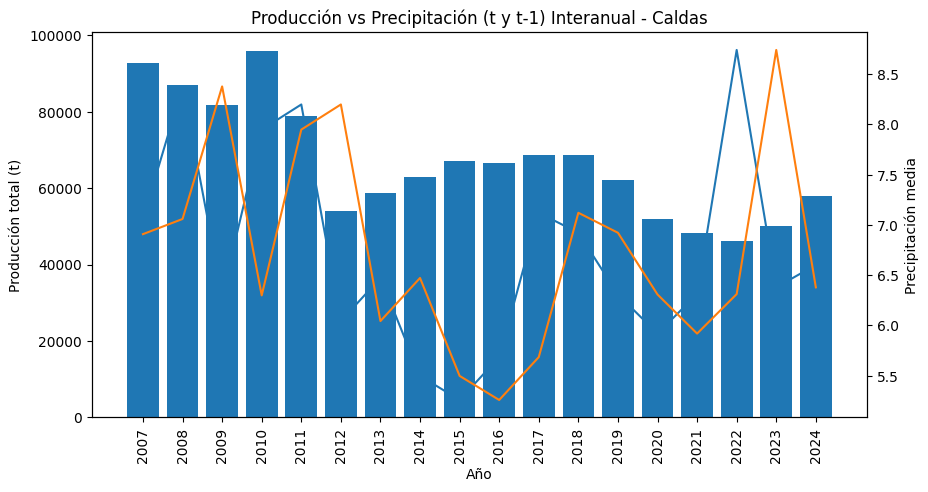

In [ ]:
# Gráfica combinada departamental producción vs precipitación

agg_anual = consolidado.groupby("anio").agg({
    "produccion_t": "sum",              # total departamental
    "precip_mean_mm": "mean",
    "precip_mean_mm_L1": "mean"
}).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xticks(agg_anual["anio"])
plt.xticks(rotation=90)

# Barras - Producción
ax1.bar(agg_anual["anio"], agg_anual["produccion_t"])
ax1.set_xlabel("Año")
ax1.set_ylabel("Producción total (t)")

# Líneas - Precipitación
ax2 = ax1.twinx()
ax2.plot(agg_anual["anio"], agg_anual["precip_mean_mm"])
ax2.plot(agg_anual["anio"], agg_anual["precip_mean_mm_L1"])
ax2.set_ylabel("Precipitación media")

plt.title("Producción vs Precipitación (t y t-1) Interanual - Caldas")
plt.show()

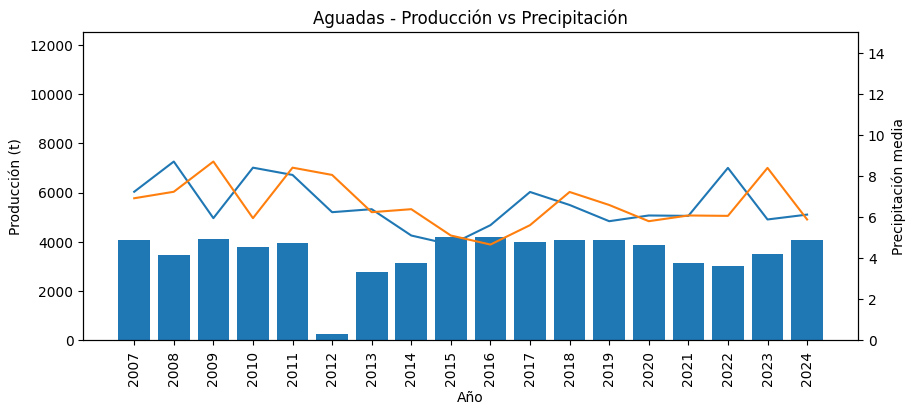

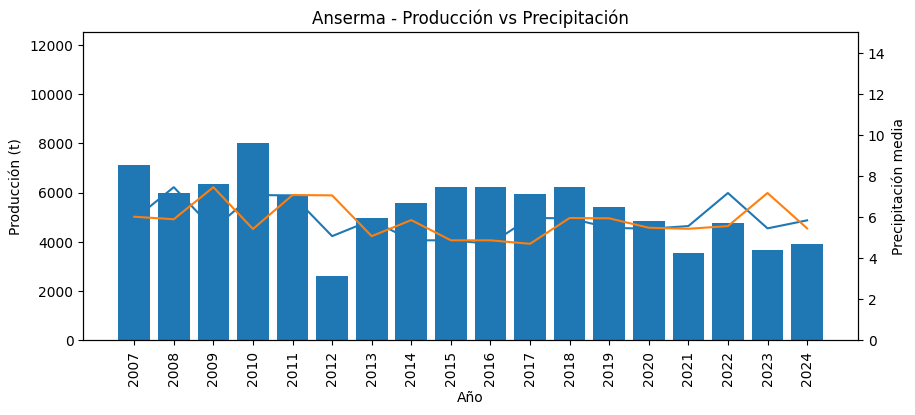

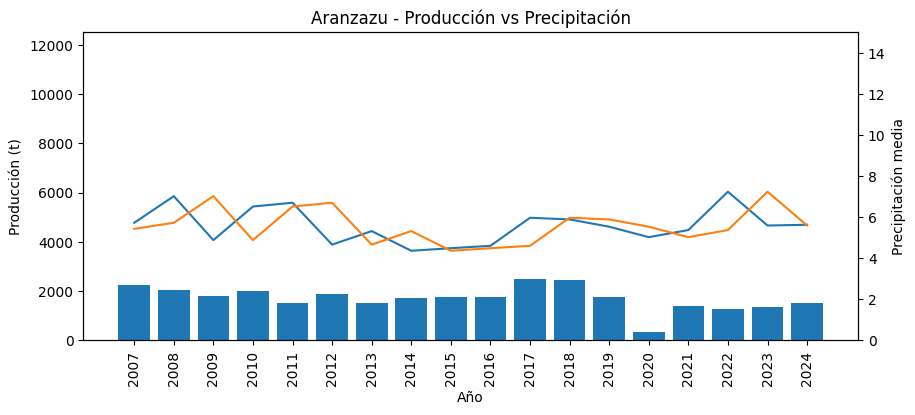

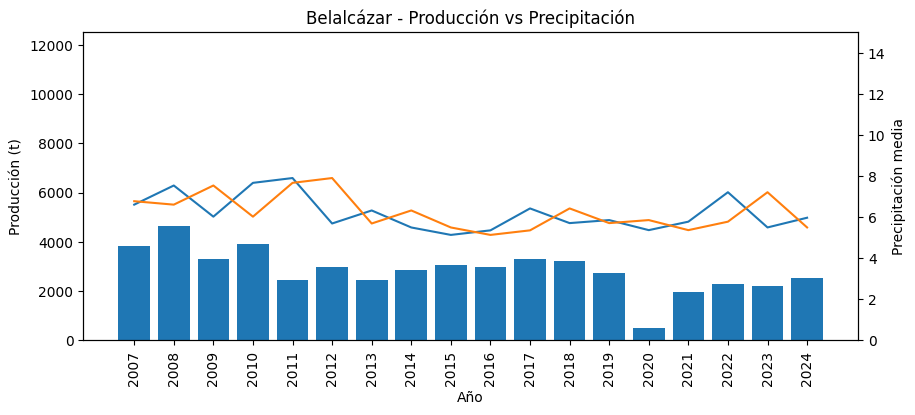

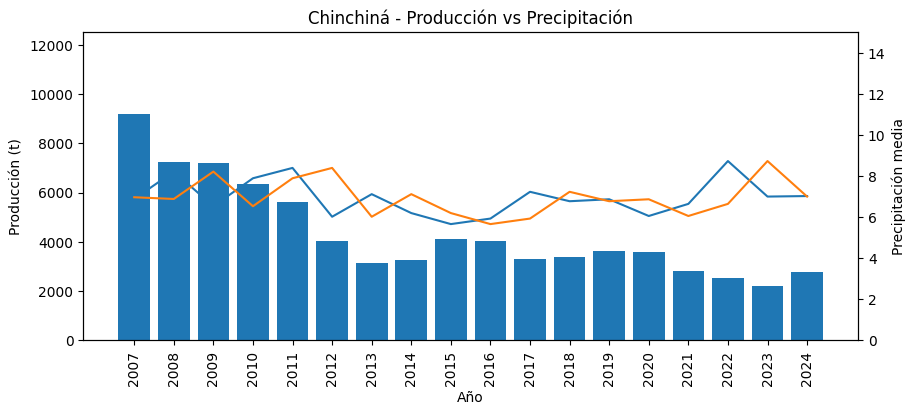

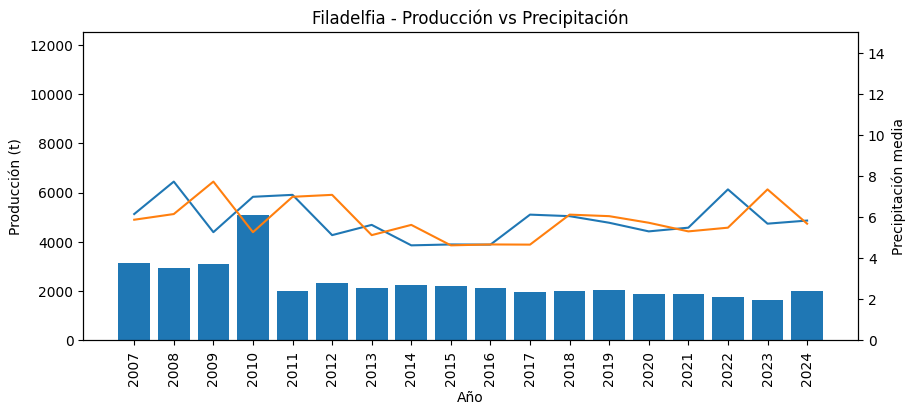

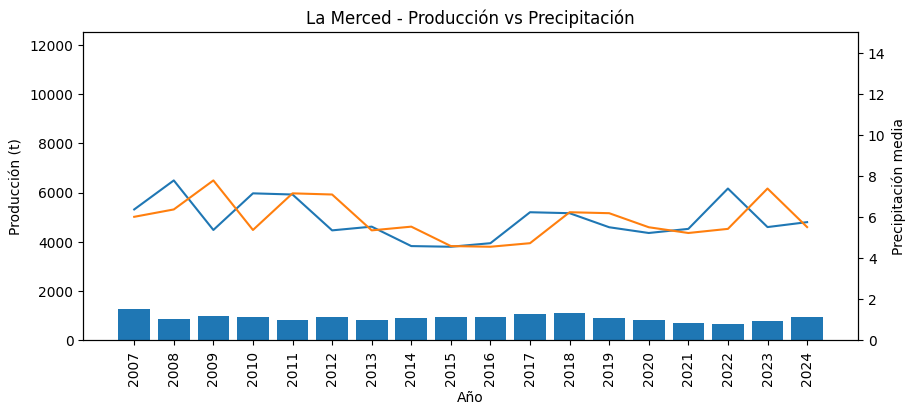

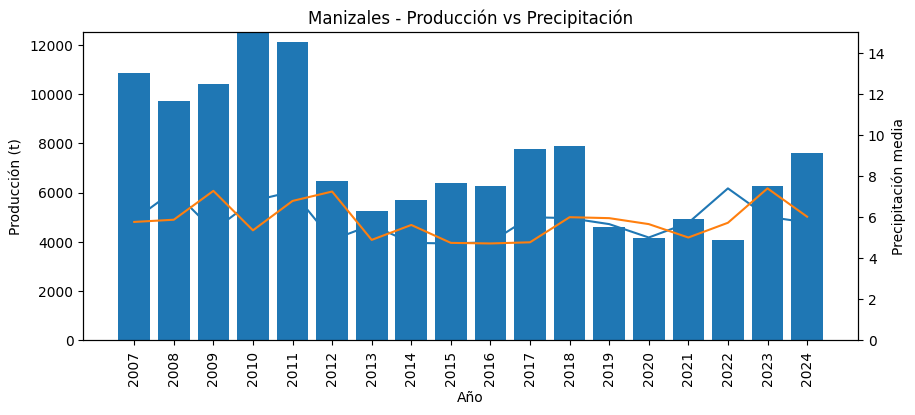

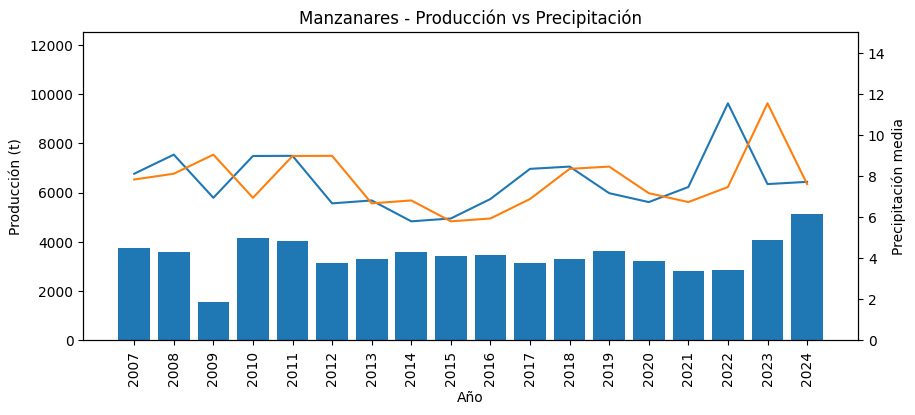

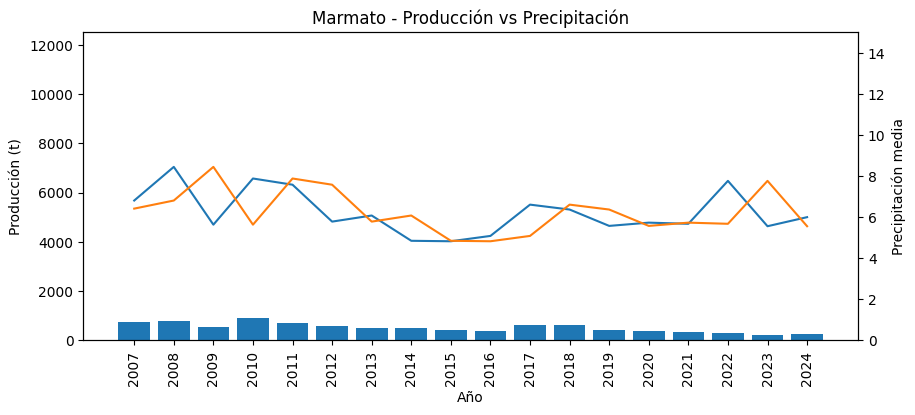

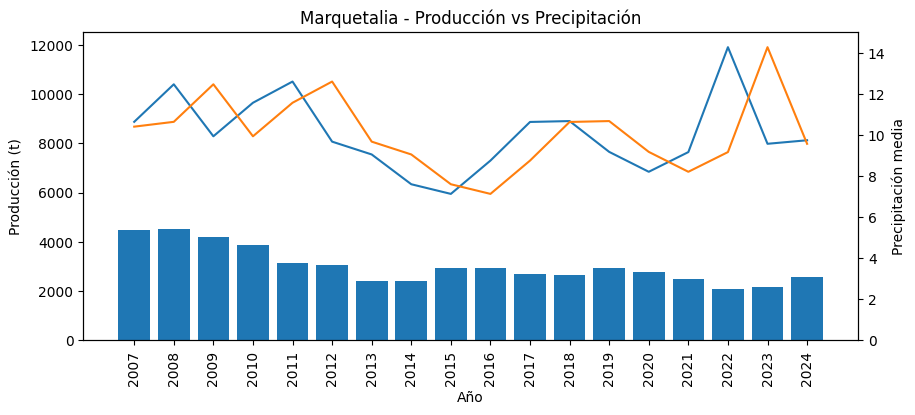

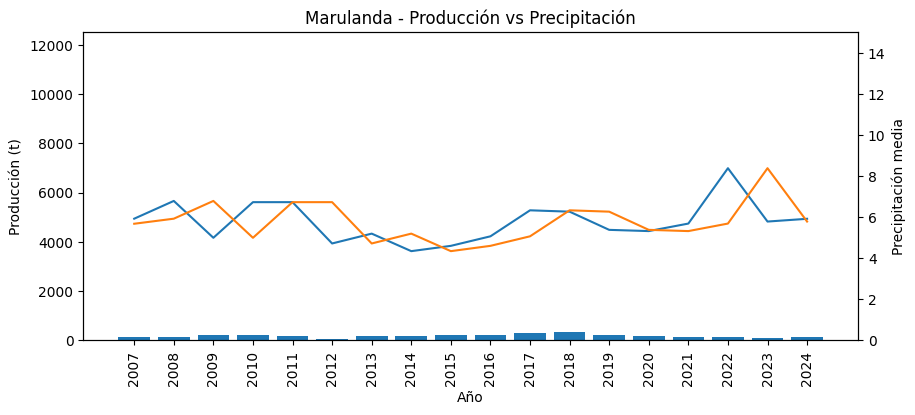

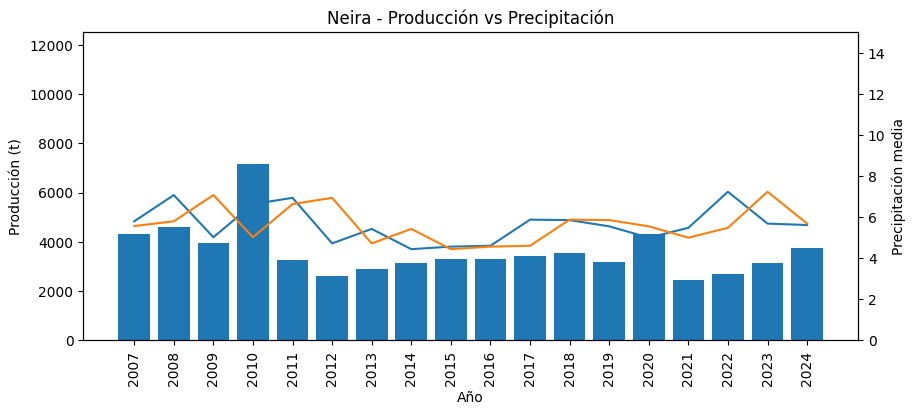

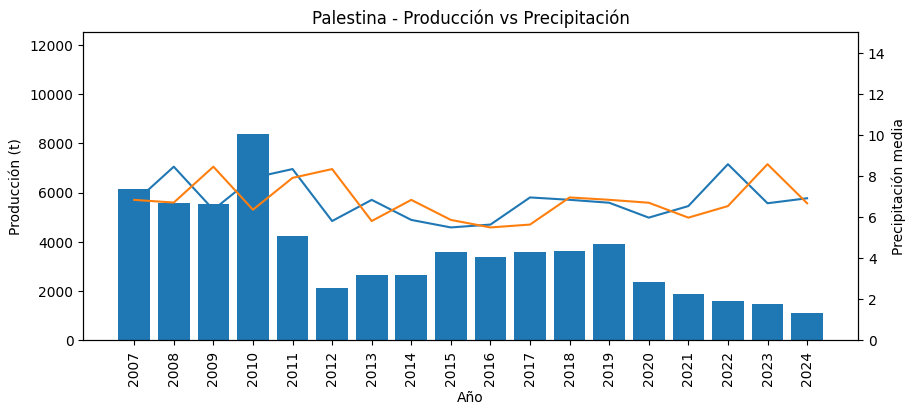

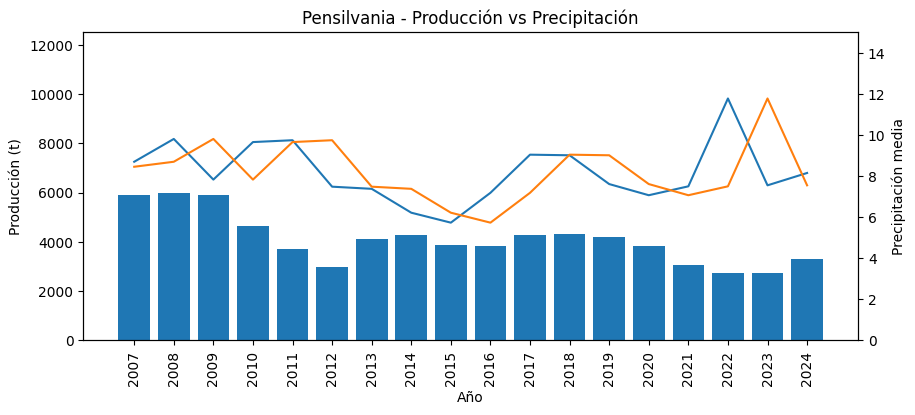

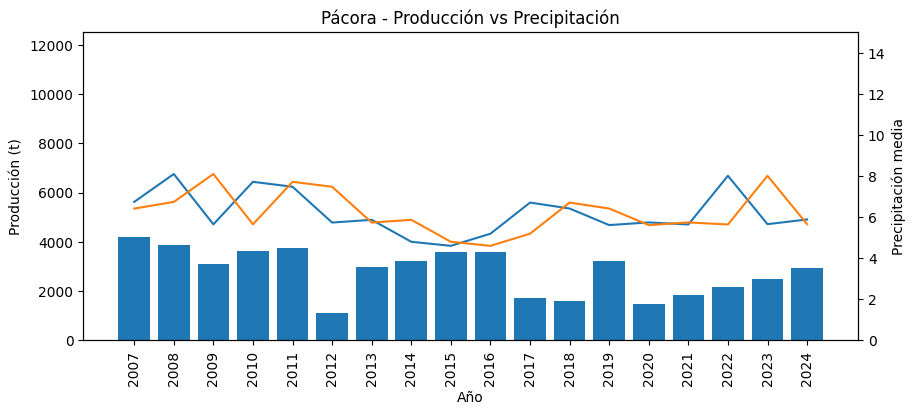

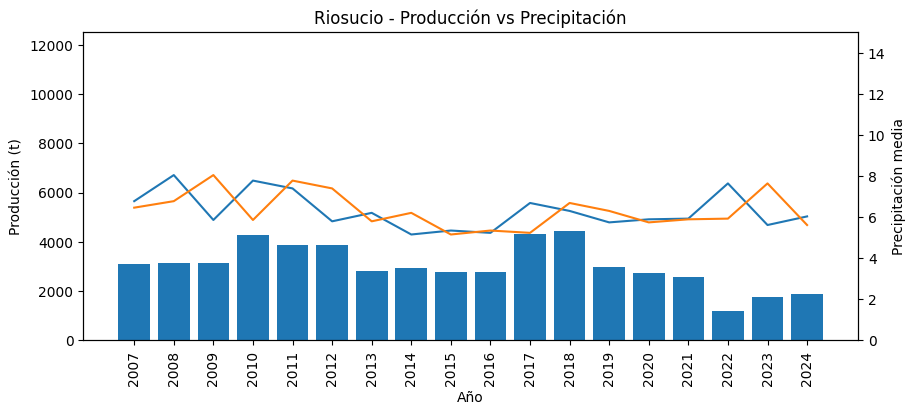

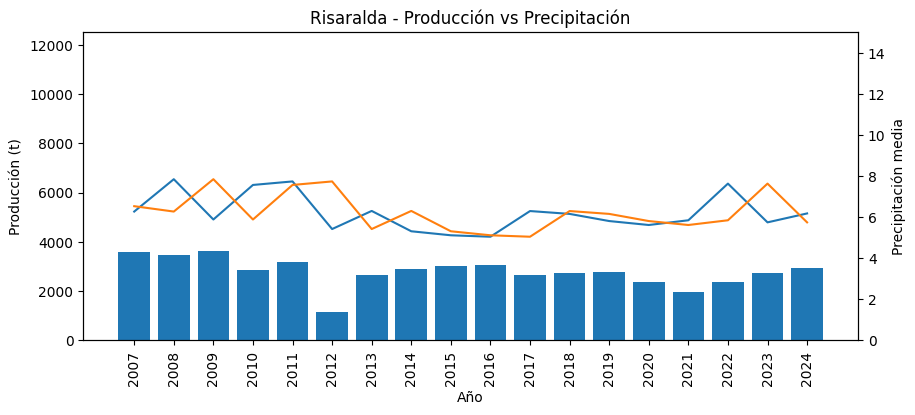

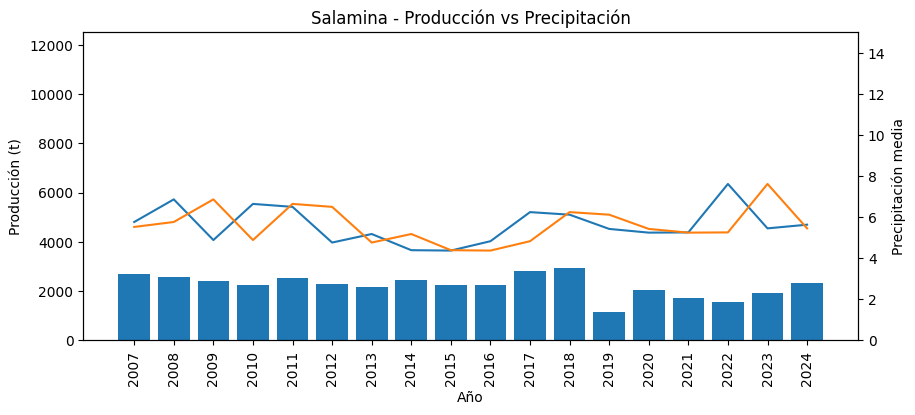

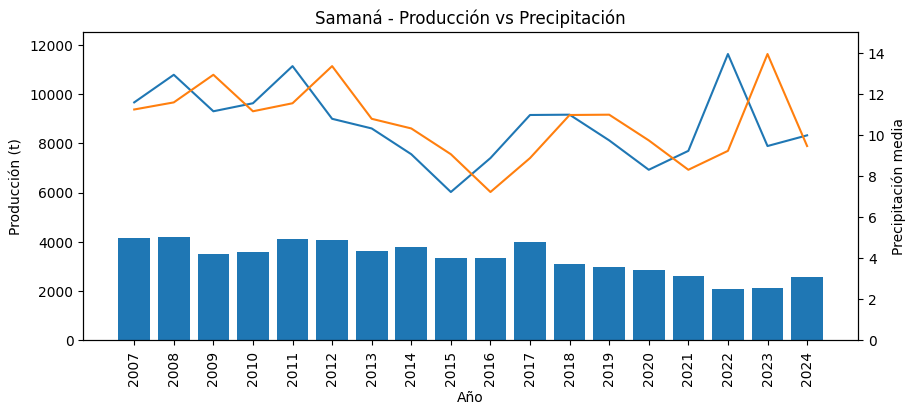

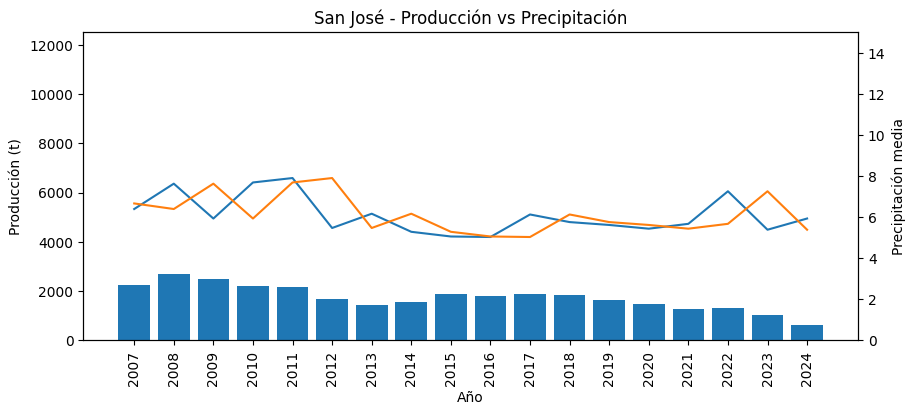

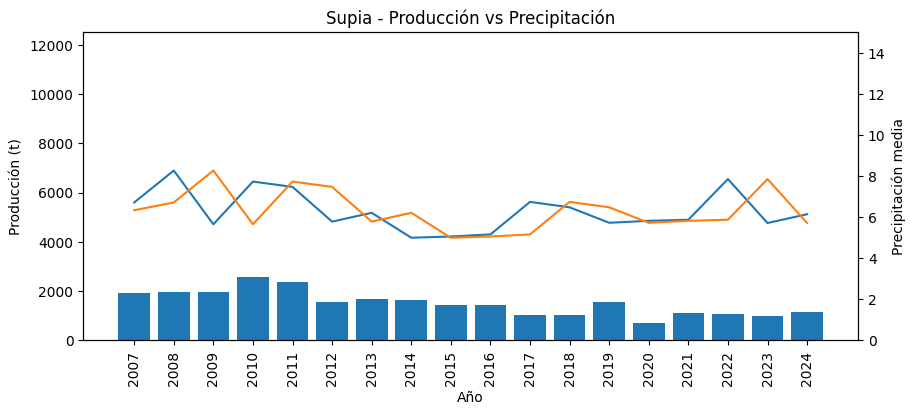

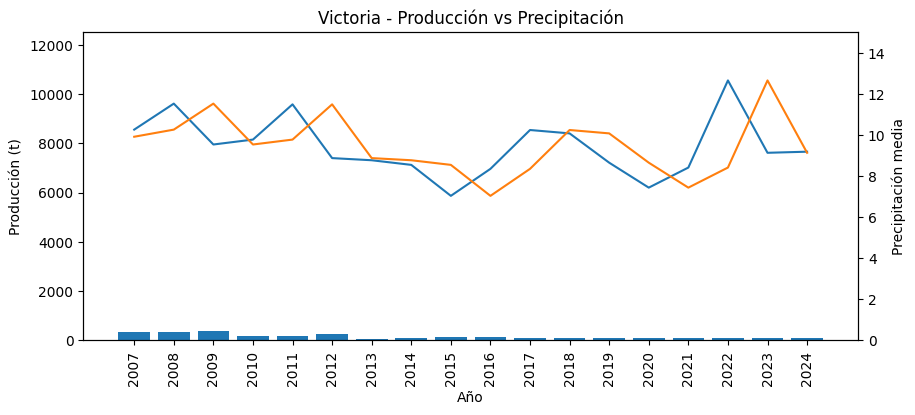

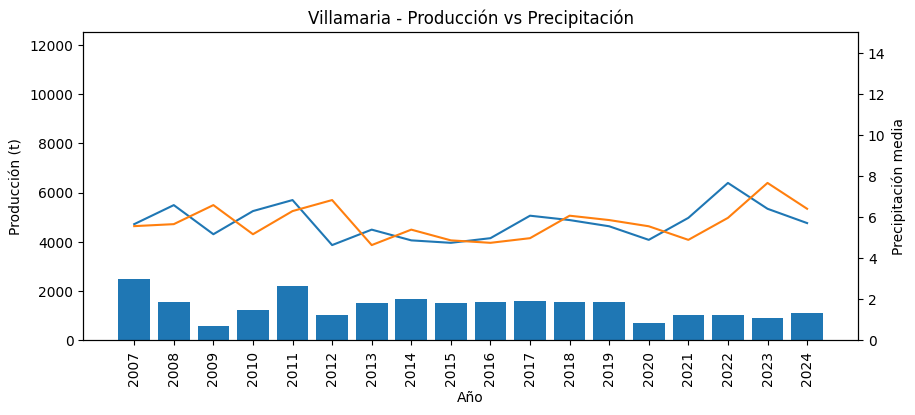

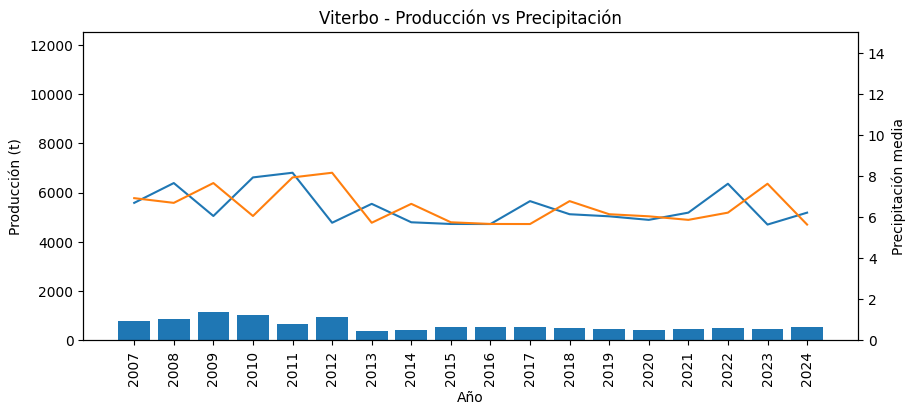

In [28]:
# Gráfica combinada municipal
municipios = consolidado["municipio"].unique()

for m in municipios:

    df_m = consolidado[consolidado["municipio"] == m].sort_values("anio")

    fig, ax1 = plt.subplots(figsize=(10, 4))
    ax1.set_xticks(df_m["anio"])
    plt.xticks(rotation=90)
    ax1.set_ylim(0, 12500)                            # Desmarcar para individualizar escalas
    
    # Producción
    ax1.bar(df_m["anio"], df_m["produccion_t"])
    ax1.set_xlabel("Año")
    ax1.set_ylabel("Producción (t)")

    # Precipitación
    ax2 = ax1.twinx()
    ax2.plot(df_m["anio"], df_m["precip_mean_mm"])
    ax2.plot(df_m["anio"], df_m["precip_mean_mm_L1"])
    ax2.set_ylabel("Precipitación media")

    ax2.set_ylim(0, 15)                                # Desmarcar para individualizar escalas

    plt.title(f"{m} - Producción vs Precipitación")
    plt.show()